In [1]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

In [2]:
BASE_DIR = r'C:\Users\PUST\Sajeeb\Image_Captioning'
WORKING_DIR = BASE_DIR
Pre_trained = 'EfficientNetB4'

In [3]:
from tensorflow.keras.applications import ResNet101V2, EfficientNetB3, EfficientNetB4
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input
# VGG16 image=224x224 output=4096
# ResNet50 image=224x224 output=2048
# ResNet101V2 image=224x224 output=2048
# EfficientNetB3 image=300x300 output=1536
# EfficientNetB4 image=380x380 output=1792

In [4]:
# load vgg16 model
model = EfficientNetB4()
# restructure the model
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
# summarize
print(model.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 380, 380, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 380, 380, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 380, 380, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 380, 380, 3)          0         ['normalization[0][0]']   

In [ ]:
# # extract features from image
# features = {}
# directory = os.path.join(BASE_DIR, 'flickr30k/Images/flickr30k_images')

# for img_name in tqdm(os.listdir(directory)):
#     # load the image from file
#     img_path = directory + '/' + img_name
#     image = load_img(img_path, target_size=(300, 300))
#     # convert image pixels to numpy array
#     image = img_to_array(image)
#     # reshape data for model
#     image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
#     # preprocess image for vgg
#     image = preprocess_input(image)
#     # extract features
#     feature = model.predict(image, verbose=0)
#     # get image ID
#     image_id = img_name.split('.')[0]
#     # store feature
#     features[image_id] = feature

In [ ]:
# # store features in pickle
# pickle.dump(features, open(os.path.join(WORKING_DIR, 'EfficientNetB3_features.pkl'), 'wb'))

In [5]:
# load features from pickle
with open(os.path.join(WORKING_DIR, Pre_trained, f'{Pre_trained}_features.pkl'), 'rb') as f:
    features = pickle.load(f)

In [6]:
# with open(os.path.join(BASE_DIR, 'banglaview.txt'), 'r') as f:
with open(os.path.join(BASE_DIR, "banglaview.txt"), "r", encoding="utf-8",) as f:
    # next(f)
    captions_doc = f.read()

In [7]:
# create mapping of image to captions
mapping = {}
# process lines
for line in tqdm(captions_doc.split('\n')):
    # split the line by comma(,)
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    # remove extension from image ID
    image_id = image_id.split('.')[0]
    # convert caption list to string
    caption = " ".join(caption)
    # create list if needed
    if image_id not in mapping:
        mapping[image_id] = []
    # store the caption
    mapping[image_id].append(caption)

  0%|          | 0/158915 [00:00<?, ?it/s]

In [8]:
len(mapping)

32447

In [9]:
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            # take one caption at a time
            caption = captions[i]
            # preprocessing steps
            # convert to lowercase
            caption = caption.lower()
            # delete digits, special chars, etc., 
#             caption = caption.replace('[^A-Za-z]', '')
            caption = caption.replace(r"!\"#$%&\(\)\*\+.,-/:;=?@\[\\\]^_`{|}~", "")
            # delete additional spaces
            caption = caption.replace('\s+', ' ')
            # add start and end tags to the caption
            caption = 'startseq ' + " ".join([word for word in         caption.split() if len(word)>1]) + ' endseq'
            captions[i] = caption

In [10]:
# before preprocess of text
mapping['10002456']

['শক্ত টুপি পরা বেশ কয়েকজন পুরুষ একটি বিশাল মেশিন পরিচালনা করছে',
 'শ্রমিকরা নিচের দিকে সরঞ্জামের ওপর তাকায়',
 'হার্ড টুপি পরা একটি মেশিনে কাজ করছে দুই ব্যক্তি',
 'একটি লম্বা কাঠামোর উপরে চারজন পুরুষ',
 'একটা বড় কাঠামোর সামনে তিনজন লোক']

In [11]:
# preprocess the text
clean(mapping)

In [12]:
# before preprocess of text
mapping['10002456']

['startseq শক্ত টুপি পরা বেশ কয়েকজন পুরুষ একটি বিশাল মেশিন পরিচালনা করছে endseq',
 'startseq শ্রমিকরা নিচের দিকে সরঞ্জামের ওপর তাকায় endseq',
 'startseq হার্ড টুপি পরা একটি মেশিনে কাজ করছে দুই ব্যক্তি endseq',
 'startseq একটি লম্বা কাঠামোর উপরে চারজন পুরুষ endseq',
 'startseq একটা বড় কাঠামোর সামনে তিনজন লোক endseq']

In [13]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)
len(all_captions)

158915

In [14]:
all_captions[:10]

['startseq এলোমেলো চুলের দুই যুবক উঠোনে আড্ডা দেওয়ার সময় তাদের হাতের দিকে তাকিয়ে আছে endseq',
 'startseq দুই যুবক বাইরে অনেক ঝোপের কাছে দাঁড়িয়ে আছে endseq',
 'startseq সবুজ শার্ট পরা দুজন লোক উঠোনে দাঁড়িয়ে আছে endseq',
 'startseq নীল শার্ট পরা একজন লোক বাগানে দাঁড়িয়ে আছে endseq',
 'startseq দুই বন্ধু একসাথে কাটানো সময় উপভোগ করছে endseq',
 'startseq শক্ত টুপি পরা বেশ কয়েকজন পুরুষ একটি বিশাল মেশিন পরিচালনা করছে endseq',
 'startseq শ্রমিকরা নিচের দিকে সরঞ্জামের ওপর তাকায় endseq',
 'startseq হার্ড টুপি পরা একটি মেশিনে কাজ করছে দুই ব্যক্তি endseq',
 'startseq একটি লম্বা কাঠামোর উপরে চারজন পুরুষ endseq',
 'startseq একটা বড় কাঠামোর সামনে তিনজন লোক endseq']

In [15]:
# tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
vocab_size

25444

In [16]:
# get maximum length of the caption available
max_length = max(len(caption.split()) for caption in all_captions)
max_length

67

In [17]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90) #
train = image_ids[:split]
test = image_ids[split:]

In [18]:
#Verifying keys before training
def verify_keys(data_keys, features):
    missing_keys = []
    for key in data_keys:
        if key not in features:
            missing_keys.append(key)
    
    if missing_keys:
        print(len(missing_keys))
image_ids = list(mapping.keys())
verify_keys(image_ids, features)

665


In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dropout, Dense, Embedding, GRU, add
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.utils import plot_model
from tqdm import tqdm
import nltk

In [20]:
# Ensure nltk resources are downloaded
nltk.download('wordnet')

# Disable TensorFlow function tracing
tf.config.experimental_run_functions_eagerly(True)

Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PUST\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [21]:
# create data generator to get data in batch (avoids session crash)
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            if key not in features:
                continue
            
            n += 1
            captions = mapping[key]
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield {"image": X1, "text": X2}, y
                X1, X2, y = list(), list(), list()
                n = 0

In [ ]:
# checkpoint_path = os.path.join(WORKING_DIR,'checkpoints')
# os.makedirs(checkpoint_path, exist_ok=True)
# ckpt = tf.train.Checkpoint(model=model, optimizer=model.optimizer)
# ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# # Restore checkpoint if exists
# start_epoch = 0
# if ckpt_manager.latest_checkpoint:
#     ckpt.restore(ckpt_manager.latest_checkpoint).expect_partial()
#     start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
# print(f"Epoch restored: {start_epoch}")

In [ ]:
import json
# Initialize history dictionary
history_dict = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

# Load history if exists
# history_path = '/kaggle/working/training_history.json'
history_path = os.path.join(WORKING_DIR, Pre_trained, 'training_history.json')
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history_dict = json.load(f)

In [24]:
# Utilize MirroredStrategy for multi-GPU support
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    inputs1 = Input(shape=(1792,), name="image")
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(512, activation='relu')(fe1)
    fe3 = BatchNormalization()(fe2)
    fe4 = Activation('relu')(fe3)
    fe5 = Dense(256, activation='relu')(fe4)
    fe6 = BatchNormalization()(fe5)
    fe7 = Activation('relu')(fe6)
    inputs2 = Input(shape=(max_length,), name="text")
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.4)(se1)
    se3 = GRU(256)(se2)
    decoder1 = add([fe7, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


In [31]:
import json
# Train the model
epochs = 10
batch_size = 32
steps = len(train) // batch_size
val_steps = len(test) // batch_size

for i in range(epochs):
    train_generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    val_generator = data_generator(test, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    history = model.fit(train_generator, epochs=1, steps_per_epoch=steps, validation_data=val_generator, validation_steps=val_steps, verbose=1)

    # Append the history values
    history_dict["train_loss"].append(history.history['loss'][0])
    history_dict["val_loss"].append(history.history['val_loss'][0])
    history_dict["train_acc"].append(history.history['accuracy'][0])
    history_dict["val_acc"].append(history.history['val_accuracy'][0])
    
    # Save history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)
    # Save checkpoint
#     ckpt_manager.save()

C:\Users\PUST\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tensorflow\python\data\ops\structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


912/912 [==============================] - 6779s 7s/step - loss: 2.6693 - accuracy: 0.4286 - val_loss: 4.4211 - val_accuracy: 0.3385


In [ ]:
import matplotlib.pyplot as plt
# Plotting the loss and accuracy graphs
epochs_range = range(len(history_dict["train_loss"]))

plt.figure(figsize=(18, 6))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_dict["train_loss"], label='Training Loss')
plt.legend(loc='upper right')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_dict["train_acc"], label='Training Accuracy')
plt.plot(epochs_range, history_dict["val_acc"], label='Validation Accuracy')
plt.legend(loc='upper right')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy vs Epochs')

plt.show()

In [33]:
# save the model
model.save(WORKING_DIR+Pre_trained+'/best_model.h5')

C:\Users\PUST\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model(os.path.join(WORKING_DIR, Pre_trained, 'best_model.h5'))

model = loaded_model


TypeError: Error when deserializing class 'InputLayer' using config={'batch_shape': [None, 1792], 'dtype': 'float32', 'sparse': False, 'name': 'image'}.

Exception encountered: Unrecognized keyword arguments: ['batch_shape']

In [34]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def predict_caption(model, image, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], max_length)
        yhat = model.predict([image, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = idx_to_word(yhat, tokenizer)
        if word is None:
            break
        in_text += " " + word
        if word == 'endseq':
            break
    return in_text

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    # load the image
    # image_name = "1001773457_577c3a7d70.jpg"
    image_id = image_name.split('.')[0]
    img_path = os.path.join(BASE_DIR, "images", image_name)
    image = Image.open(img_path)
    captions = mapping[image_id]
    print('---------------------Actual---------------------')
    for caption in captions:
        print(caption)
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)

---------------------Actual---------------------
startseq গোলাপী পোশাক পরা একটি শিশু প্রবেশ পথে সিঁড়ি বেয়ে উপরে উঠছে endseq
startseq একটি গোলাপী পোশাক পরা ছোট্ট মেয়ে একটি কাঠের ঘরে যাচ্ছে endseq
startseq একটি ছোট মেয়ে তার খেলার ঘরের সিঁড়ি বেয়ে উঠছে endseq
startseq একটি ছোট মেয়ে একটি কাঠের খেলাঘরে আরোহণ করছে endseq
startseq একটি মেয়ে একটি কাঠের ভবনে যাচ্ছে endseq
--------------------Predicted--------------------
startseq একটি ছোট শিশু একটি কাঠের খেলাঘরে আরোহণ করছে endseq


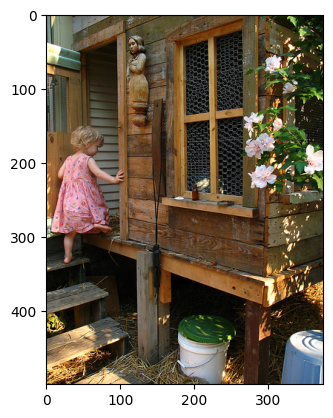

In [36]:
generate_caption("1000268201.jpg")

---------------------Actual---------------------
startseq ছোট্ট মেয়েটি তার সাদা কুকুরকে ধরার জন্য বাতাসে খাবার ছুড়ে দিচ্ছে endseq
startseq একটি শিশু একটি সাদা কুকুরকে ধরার জন্য কিছু ছুড়ে দেয় endseq
startseq একটি ছোট মেয়ে একটি সাদা কুকুরের সাথে আনতে খেলছে endseq
startseq একটি মেয়ে তার সাদা কুকুরকে ট্রিট দিয়ে প্রশিক্ষণ দিচ্ছে endseq
startseq মেয়ে জাম্পিং কুকুরকে ট্রিট দিচ্ছে endseq
--------------------Predicted--------------------
startseq একটি সাদা কুকুর একটি সাদা কুকুরের সাথে খেলছে endseq


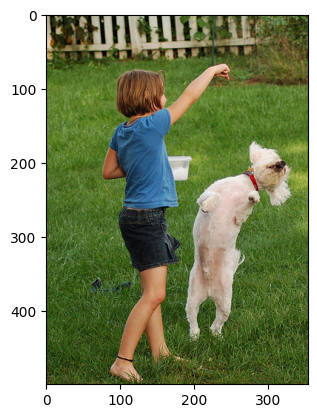

In [37]:
generate_caption("246094557.jpg")

---------------------Actual---------------------
startseq একটি সুন্দর রৌদ্রোজ্জ্বল দিনে ব্যাকগ্রাউন্ডে একটি দৃশ্য সহ সার্ফার তার একটি চাল সম্পাদন করছে endseq
startseq একজন দক্ষ সার্ফার তার বোর্ডের ডগা দখল করে যখন তরঙ্গে চড়ে endseq
startseq একজন পুরুষ সার্ফার সমুদ্রে একটি সার্ফবোর্ডে ঘুরছেন endseq
startseq একটি কালো ওয়েটস্যুট পরা একজন সার্ফার একটি ছোট তরঙ্গ ধরছে endseq
startseq মানুষ একটি তরঙ্গ সার্ফিং এবং একটি কৌশল বন্ধ টেনে endseq
--------------------Predicted--------------------
startseq একটি ছেলে একটি বড় পাথরের উপর একটি বড় পাথরের উপর বসে আছে endseq


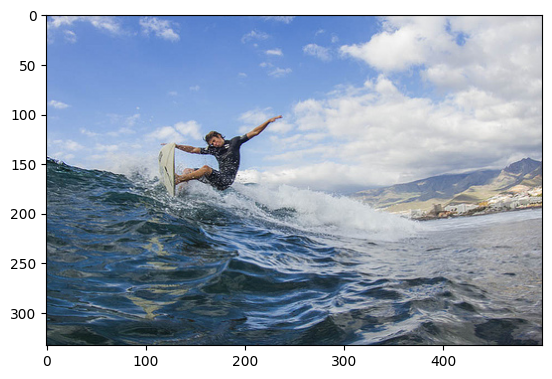

In [38]:
generate_caption("8247042603.jpg")

---------------------Actual---------------------
startseq সম্পূর্ণ কালো পোশাক পরা একজন সামুরাই যোদ্ধা একটি বহিরঙ্গন প্রশিক্ষণ মাদুরের উপর খাপ থেকে তার তলোয়ার নিয়ে যাচ্ছেন endseq
startseq একটি কালো মার্শাল আর্ট স্যুট পরা একজন ব্যক্তি একটি মাঠে প্রশিক্ষণের মাদুরে একটি তলোয়ার খুলে ফেলছেন endseq
startseq একটি তলোয়ার এবং ঐতিহ্যগত যুদ্ধের গিয়ার সহ একটি লোক লড়াইয়ের জন্য প্রস্তুত হচ্ছে endseq
startseq কালো রঙের একজন লোক সবুজ পাহাড়ের সামনে একটি তরবারি চালাচ্ছে endseq
startseq কালো পোশাক পরা এক ব্যক্তি সবুজ মাঠে কারাতে করছেন endseq
--------------------Predicted--------------------
startseq একটি কালো টুপি এবং কালো জ্যাকেট পরা একজন লোক একটি তলোয়ার ধরে আছে endseq


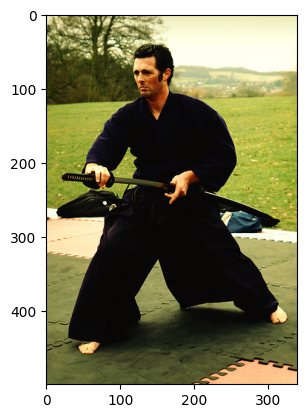

In [39]:
generate_caption("104835889.jpg")

---------------------Actual---------------------
startseq একদল হাইকার কিছু পাহাড়ের সামনে মাটিতে বিশ্রাম নিচ্ছে endseq
startseq বেশ কিছু হাইকার একটি পাহাড়ের সামনে তাদের গিয়ার নিয়ে বিশ্রাম নিচ্ছেন endseq
startseq পর্বতারোহীদের দল একটি পাহাড়ের সামনে বিশ্রাম নিচ্ছে endseq
startseq মানুষ পটভূমিতে পাহাড়ের সাথে ক্যাম্প করে endseq
startseq একদল ব্যাকপ্যাকার শুকনো মাটিতে শুয়ে আছে endseq
--------------------Predicted--------------------
startseq একটি পাহাড়ের কাছে একটি পাহাড়ের চূড়ায় তিনজন লোক বসে আছে endseq


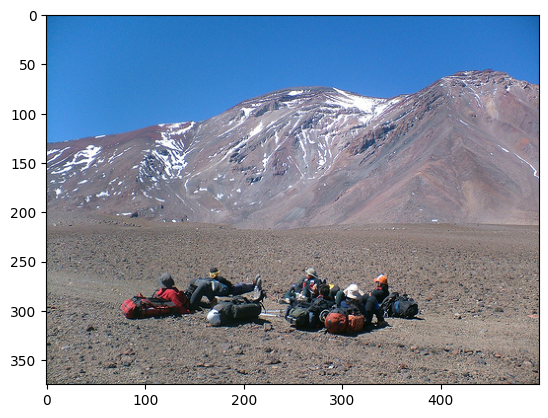

In [40]:
generate_caption("1093716555.jpg")

---------------------Actual---------------------
startseq একটি কমলা সার্ফবোর্ডের পিছনে বাদামী চুল সহ জলে একজন সাদা মহিলা endseq
startseq একজন মহিলা সার্ফার একটি বোর্ডের পাশে সমুদ্রের ভিতরে হাসছেন endseq
startseq ওয়েকবোর্ডে চড়ে এক নারী পানিতে পড়ে যান endseq
startseq একজন মহিলা জলে ওয়েকবোর্ডের জন্য প্রস্তুত endseq
startseq পানিতে একজন মহিলা ওয়েকবোর্ডিং করছেন endseq
--------------------Predicted--------------------
startseq একটি ছোট শিশু একটি লাল এবং সাদা স্ফীত স্লাইডের নিচে যাচ্ছে endseq


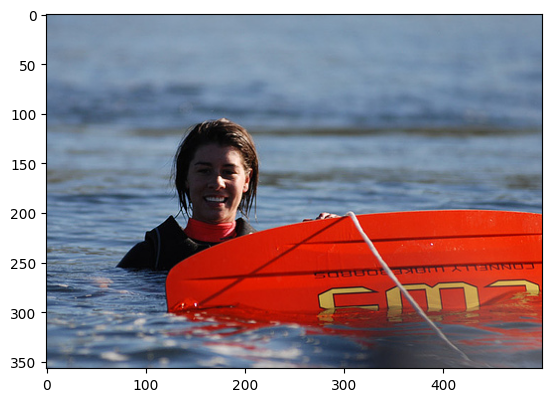

In [41]:
generate_caption("728044957.jpg")

---------------------Actual---------------------
startseq বেগুনি রঙের টপ পরা একটি মেয়ে একটি ঝোপের সামনে ঘাসের উপর নিজের এবং অন্য একটি মেয়ের মধ্যে একটি বাচ্চাকে ধরে রেখেছে endseq
startseq তিনটি ছোট বাচ্চা ঘাসে বসে আছে endseq
startseq তিনটি ছোট মেয়ে ঘাসের উপর বসে আছে endseq
startseq তিনজন তরুণী লনে বসে আছে endseq
startseq তিন শিশু ঘাসে বসে আছে endseq
--------------------Predicted--------------------
startseq একটি ছোট মেয়ে ঘাসে বসে একটি ছোট মেয়েকে খাওয়ানোর জন্য একটি ছোট মেয়ের দিকে তাকিয়ে আছে endseq


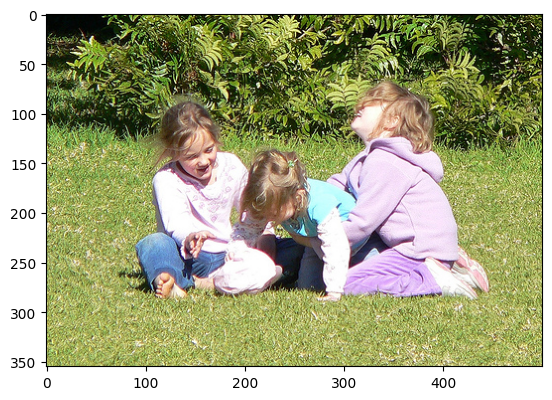

In [42]:
generate_caption("368954110.jpg")

---------------------Actual---------------------
startseq একটি বোতামযুক্ত শার্ট এবং ভিনটেজ-স্টাইলের সানগ্লাস পরে মঞ্চে একজন তরুণ অভিনয়শিল্পী তার গান গাইছেন endseq
startseq সানগ্লাস এবং হালকা নীল শর্ট-হাতা শার্ট পরা একজন শ্যামাঙ্গিনী ব্যক্তি একটি মাইক্রোফোনে গান গাচ্ছেন endseq
startseq হালকা নীল শার্ট পরা একজন যুবক মাইক্রোফোনে কথা বলছে বা গান করছে endseq
startseq সানগ্লাস পরা একজন সাদা লোক মাইক্রোফোন নিয়ে গান গাইছে endseq
startseq একজন তীক্ষ্ণ পোশাক পরা লোক মাইক্রোফোনে গান গাইছে endseq
--------------------Predicted--------------------
startseq একজন লোক মাইক্রোফোনে গান গাইছে endseq


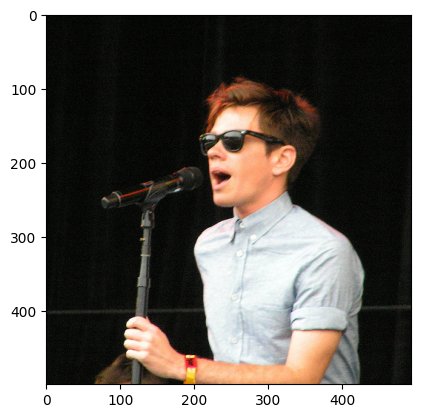

In [43]:
generate_caption("7773568122.jpg")

---------------------Actual---------------------
startseq সবুজ এবং সাদা চামড়ার আঁটসাঁট পোশাক এবং একটি লাল এবং সাদা সাইকেল হেলমেট পরা একজন ব্যক্তি হলুদ রঙের বেড়া এবং কমলা এবং কালো শঙ্কুর সামনে সাইকেল চালাচ্ছেন endseq
startseq সাদা এবং সবুজ সাইকেল শার্ট এবং হেলমেট পরে সাইকেলে চড়ে মানুষ endseq
startseq একটি সাইক্লিস্ট প্যাডেল হলুদ বেড়া এবং নির্মাণ মার্কার অতিক্রম করে endseq
startseq সবুজ এবং সাদা রঙের একজন লোক সাইকেলে চড়ে যাচ্ছে endseq
startseq একটি সাইকেল আরোহী একটি তীক্ষ্ণ বাঁক করতে কঠিন হেলান endseq
--------------------Predicted--------------------
startseq একটি লাল শার্ট এবং একটি হেলমেট পরা একজন ব্যক্তি একটি বাইক রেসে একটি বাইক চালাচ্ছেন endseq


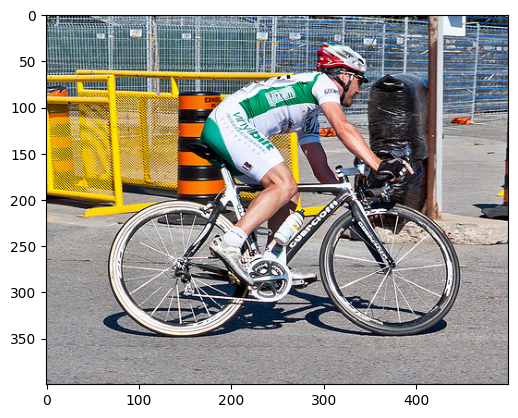

In [44]:
generate_caption("7567595412.jpg")

In [45]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.97)
sample_test = image_ids[split:]

In [46]:
# Code for prediction with GPU
from nltk.translate.bleu_score import corpus_bleu

actual, predicted = list(), list()

for key in tqdm(sample_test):
    if key not in features:
        continue
    captions = mapping[key]
    with tf.device('/GPU:0'):
        y_pred = predict_caption(model, features[key], tokenizer, max_length)
    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()
    actual.append(actual_captions)
    predicted.append(y_pred)

print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))
print("BLEU-3: %f" % corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0)))
print("BLEU-4: %f" % corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)))

100%|██████████| 974/974 [1:07:19<00:00,  4.15s/it]


BLEU-1: 0.539687
BLEU-2: 0.344282
BLEU-3: 0.204457
BLEU-4: 0.116369


In [47]:
pip install nltk rouge-score pycocotools git+https://github.com/salaniz/pycocoevalcap

  Running command git clone --filter=blob:none --quiet https://github.com/salaniz/pycocoevalcap 'C:\Users\PUST\AppData\Local\Temp\pip-req-build-y62ljhkt'

[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: C:\Users\PUST\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



  Cloning https://github.com/salaniz/pycocoevalcap to c:\users\pust\appdata\local\temp\pip-req-build-y62ljhkt
  Resolved https://github.com/salaniz/pycocoevalcap to commit a24f74c408c918f1f4ec34e9514bc8a76ce41ffd
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24972 sha256=5a098be8501c6fa5ea746be763bfcf11451a1c289ba654b0358d7bf002b2db4e
  Stored in directory: c:\users\pust\appdata\local\pip\cache\wheels\5f\dd\89\461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
  Created wheel for pycocoevalcap: filename=pycocoevalcap-1.2-py3-none-any.whl size=104313474 sha256=a939fa0356535ad7eff4a46d2542a03a641a51582b522a9c3f1f5cf5e22d6918
  Stored in directory: C:\Users\PUST\AppData\Local\Temp\pip-ephem-wheel-cache-tyuj_gvx\wheels\43\54\73\3e2c6d4ace7657958cde52ac6

In [48]:
import nltk
from rouge_score import rouge_scorer
from pycocotools.coco import COCO
from pycocoevalcap.eval import COCOEvalCap
import os

# Ensure nltk resources are downloaded
nltk.download('wordnet')

In [ ]:
# Function to calculate ROUGE score
def calculate_rouge(actual, predicted):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = {'rouge1': 0, 'rouge2': 0, 'rougeL': 0}
    for a, p in zip(actual, predicted):
        scores = scorer.score(' '.join(a[0]), ' '.join(p))
        for key in rouge_scores.keys():
            rouge_scores[key] += scores[key].fmeasure
    for key in rouge_scores.keys():
        rouge_scores[key] /= len(predicted)
    return rouge_scores
# Calculate ROUGE
rouge = calculate_rouge(actual, predicted)
print("ROUGE-1: %f" % rouge['rouge1'])
print("ROUGE-2: %f" % rouge['rouge2'])
print("ROUGE-L: %f" % rouge['rougeL'])

In [ ]:
generate_caption("745966757.jpg")

In [ ]:
generate_caption("2384353160.jpg")

In [ ]:
generate_caption("2851931813.jpg")

In [ ]:
import json
# Initialize history dictionary
history_dict = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

# Load history if exists
# history_path = '/kaggle/working/training_history.json'
history_path = os.path.join(WORKING_DIR, 'ResNet50', 'training_history.json')
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history_dict = json.load(f)

In [ ]:
import matplotlib.pyplot as plt
# Plotting the loss and accuracy graphs
epochs_range = range(len(history_dict["train_loss"]))

plt.figure(figsize=(18, 6))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_dict["train_loss"], label='Training Loss')
plt.legend(loc='upper right')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_dict["train_acc"], label='Training Accuracy')
plt.plot(epochs_range, history_dict["val_acc"], label='Validation Accuracy')
plt.legend(loc='upper right')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy vs Epochs')

plt.show()